In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

In [11]:
# 1. Téléchargement des données 
actif="SPY"
start_date="2014-01-01"
end_date="2026-01-01"
data=yf.download(actif,start_date, end_date,progress=False)

In [12]:
if isinstance(data.columns, pd.MultiIndex):
  data.columns = data.columns.get_level_values(0)

In [13]:
# 2. Calcul des Moyennes Mobiles (50 et 200 jours)
data["SMA_Short"] = data["Close"].rolling(window=50).mean()
data["SMA_Long"] = data["Close"].rolling(window=200).mean()

In [14]:
# 3. Génération des signaux et de la Position
data["Signal"] = np.where(data["SMA_Short"] > data["SMA_Long"], 1, 0)
# Décalage de la position d'une période pour éviter le look-ahead bias
data["Position"] = data["Signal"].shift(1)

In [15]:
# 4. Calcul des rendements
data["Market_Returns"] = data["Close"].pct_change()
data["Strategy_Returns"] = data["Position"] * data["Market_Returns"]

In [18]:
data = data.dropna().copy()

In [19]:
# 5. Courbes de capital (Equity Curves)
data["Market_Equity"] = (1 + data["Market_Returns"]).cumprod()
data["Strategy_Equity"] = (1 + data["Strategy_Returns"]).cumprod()

In [25]:
# 6. Fonction de calcul des métriques de performance
def calculate_metrics(returns, name="Strategy"):
  total_return = (1 + returns).prod() - 1
  annualized_return = (1 + total_return) ** (252 / len(returns)) - 1
  annualized_vol = returns.std() * np.sqrt(252)
  # Sharpe ratio (taux sans risque supposé à 0% pour simplifier)
  sharpe_ratio = (
      (returns.mean() * 252) / annualized_vol if annualized_vol != 0 else 0
  )
# Max Drawdown
  cum_returns = (1 + returns).cumprod()
  pic = cum_returns.cummax()
  drawdown = (cum_returns - pic) / pic
  max_drawdown = drawdown.min()

  # Affichage des résultats
  print(f"--- Performances : {name} ---")
  print(f"Rendement Total     : {total_return * 100:.2f}%")
  print(f"Rendement Annualisé : {annualized_return * 100:.2f}%")
  print(f"Volatilité Ann.     : {annualized_vol * 100:.2f}%")
  print(f"Ratio de Sharpe     : {sharpe_ratio:.2f}")
  print(f"Max Drawdown        : {max_drawdown * 100:.2f}%\n")

In [26]:
calculate_metrics(data["Market_Returns"], name="Buy & Hold (SPY)")
calculate_metrics(data["Strategy_Returns"], name="Moving Average Crossover")

--- Performances : Buy & Hold (SPY) ---
Rendement Total     : 342.91%
Rendement Annualisé : 14.23%
Volatilité Ann.     : 17.70%
Ratio de Sharpe     : 0.84
Max Drawdown        : -33.72%

--- Performances : Moving Average Crossover ---
Rendement Total     : 155.07%
Rendement Annualisé : 8.73%
Volatilité Ann.     : 14.90%
Ratio de Sharpe     : 0.64
Max Drawdown        : -33.72%



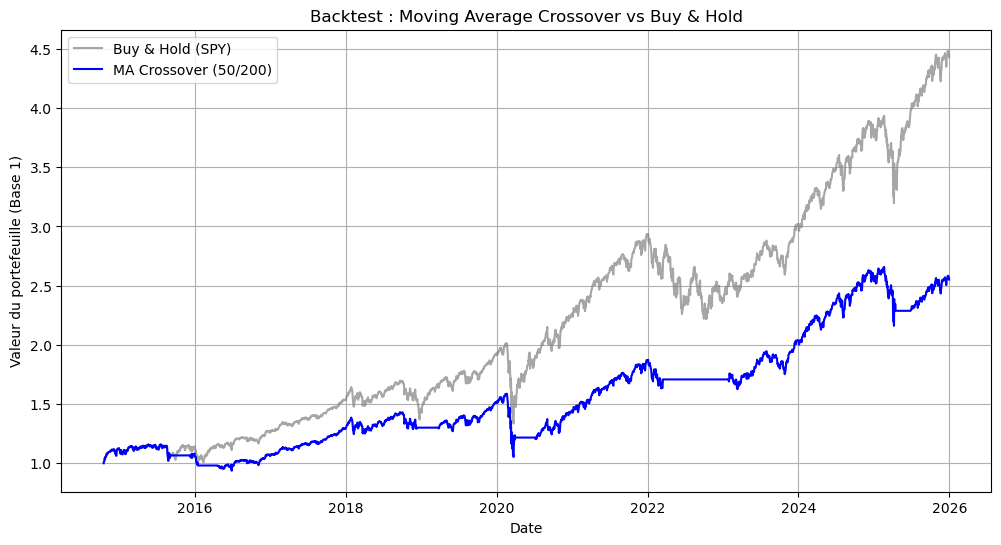

In [27]:
# 7. Visualisation
plt.figure(figsize=(12, 6))
plt.plot(
    data.index,
    data["Market_Equity"],
    label="Buy & Hold (SPY)",
    alpha=0.7,
    color="gray",
)
plt.plot(
    data.index,
    data["Strategy_Equity"],
    label="MA Crossover (50/200)",
    color="blue",
)
plt.title("Backtest : Moving Average Crossover vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Valeur du portefeuille")
plt.legend()
plt.grid(True)
plt.show()